# Price Point - EDA
Uses `master_dataset.csv` built by `src/data_cleaning.py` - SKU-week grain, 49 SKUs × 157 weeks.

In [3]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from data_cleaning import build_master_dataset

pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (10, 5)

df = build_master_dataset(save=True)
print(df.shape)
df.head()

(7693, 24)


,SKU_ID,Category,Week_Start_Date,Quantity_Sold,Total_Revenue,Avg_Discount_Pct,Max_Discount_Pct,On_Promo,Avg_Effective_Price_INR,Avg_Listed_Price_INR,...,Ending_Inventory_Units,Stockout_Flag,Product_Name,Base_Cost_INR,Margin_Target_Pct,Shelf_Life_Days,Gross_Margin_Pct,Price_vs_Competitor_Gap_Pct,Log_Price,Log_Qty
0,SKU0001,Electronics,2022-01-03,137,1329135.44,0.000000,0.00,False,9701.718540,9701.718540,...,2479.0,0.0,Smart Earbuds,8000,0.18,NaN,0.175404,0.096477,9.180058,4.919981
1,SKU0001,Electronics,2022-01-10,132,1290358.31,0.000000,0.00,False,9775.441742,9775.441742,...,3097.0,0.0,Smart Earbuds,8000,0.18,NaN,0.181623,0.105347,9.187629,4.882802
2,SKU0001,Electronics,2022-01-17,148,1230599.92,0.102857,0.18,True,8314.864324,9576.438919,...,3724.0,0.0,Smart Earbuds,8000,0.18,NaN,0.037868,0.712607,9.025800,4.997212
3,SKU0001,Electronics,2022-01-24,207,1793907.28,0.051429,0.18,True,8666.218744,9552.200000,...,4363.0,0.0,Smart Earbuds,8000,0.18,NaN,0.076875,-0.042174,9.067188,5.332719
4,SKU0001,Electronics,2022-01-31,132,1251263.57,0.000000,0.00,False,9479.269470,9479.269470,...,5099.0,0.0,Smart Earbuds,8000,0.18,NaN,0.156053,0.015814,9.156863,4.882802


## 1. Price distribution by category
Right now prices are set manually by category managers - this should show up as inconsistent
price-to-cost ratios and wide within-category spread.

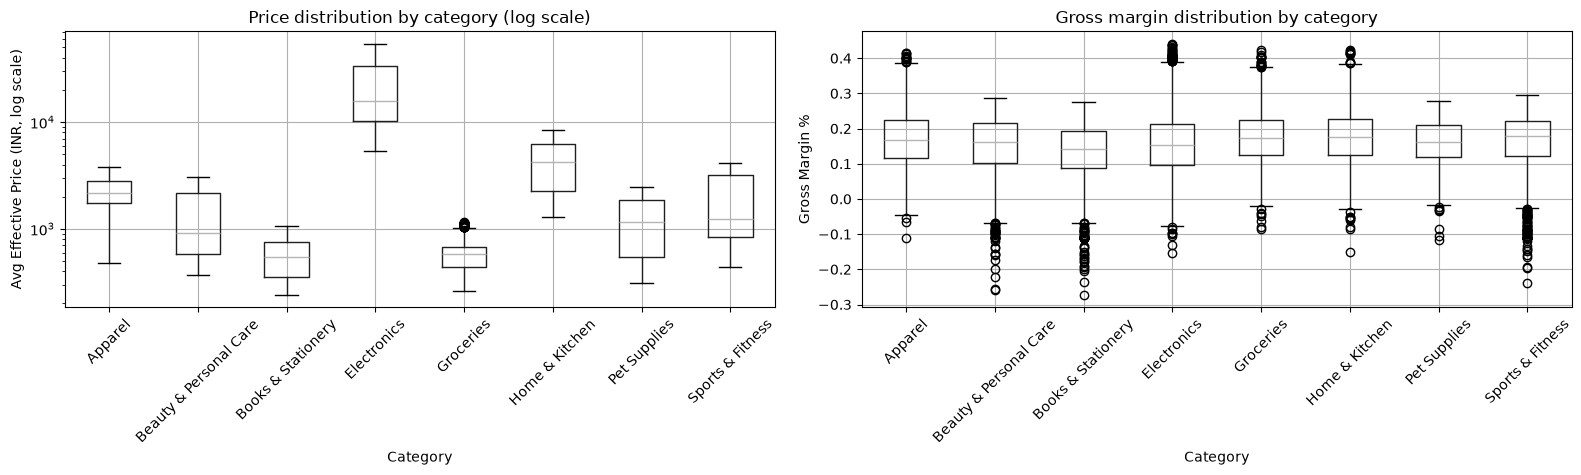

                            mean       std
Category                                  
Electronics             0.163846  0.103004
Sports & Fitness        0.153380  0.097795
Beauty & Personal Care  0.145570  0.094023
Books & Stationery      0.126327  0.093091
Home & Kitchen          0.178224  0.088398
Apparel                 0.174311  0.085032
Groceries               0.176866  0.083557
Pet Supplies            0.158413  0.065182


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order = df.groupby('Category')['Avg_Effective_Price_INR'].median().sort_values(ascending=False).index
df.boxplot(column='Avg_Effective_Price_INR', by='Category', ax=axes[0], rot=45)
axes[0].set_yscale('log')
axes[0].set_title('Price distribution by category (log scale)')
axes[0].set_ylabel('Avg Effective Price (INR, log scale)')

df.boxplot(column='Gross_Margin_Pct', by='Category', ax=axes[1], rot=45)
axes[1].set_title('Gross margin distribution by category')
axes[1].set_ylabel('Gross Margin %')

plt.suptitle('')
plt.tight_layout()
plt.show()

print(df.groupby('Category')['Gross_Margin_Pct'].agg(['mean','std']).sort_values('std', ascending=False))

**Note:** Product prices vary substantially across categories, with Electronics and Home & Kitchen occupying the highest price ranges, while Books & Stationery and Groceries contain the lowest-priced products. Gross margin distributions, however, are relatively similar across categories, with median margins generally between **15% and 20%**. Electronics exhibits the greatest variability in gross margins (std ≈ **10.3%**), followed by Sports & Fitness and Beauty & Personal Care, suggesting more inconsistent pricing decisions within these categories. In contrast, categories with lower margin variability appear to follow more consistent pricing strategies and may require less immediate pricing optimization.

**Takeaway:** Categories with higher gross margin variability are likely to have more inconsistent pricing decisions and may offer the greatest opportunity for pricing optimization.

## 2. Discounting patterns
How often and how deep is discounting, by category - and does it cluster around promo weeks?

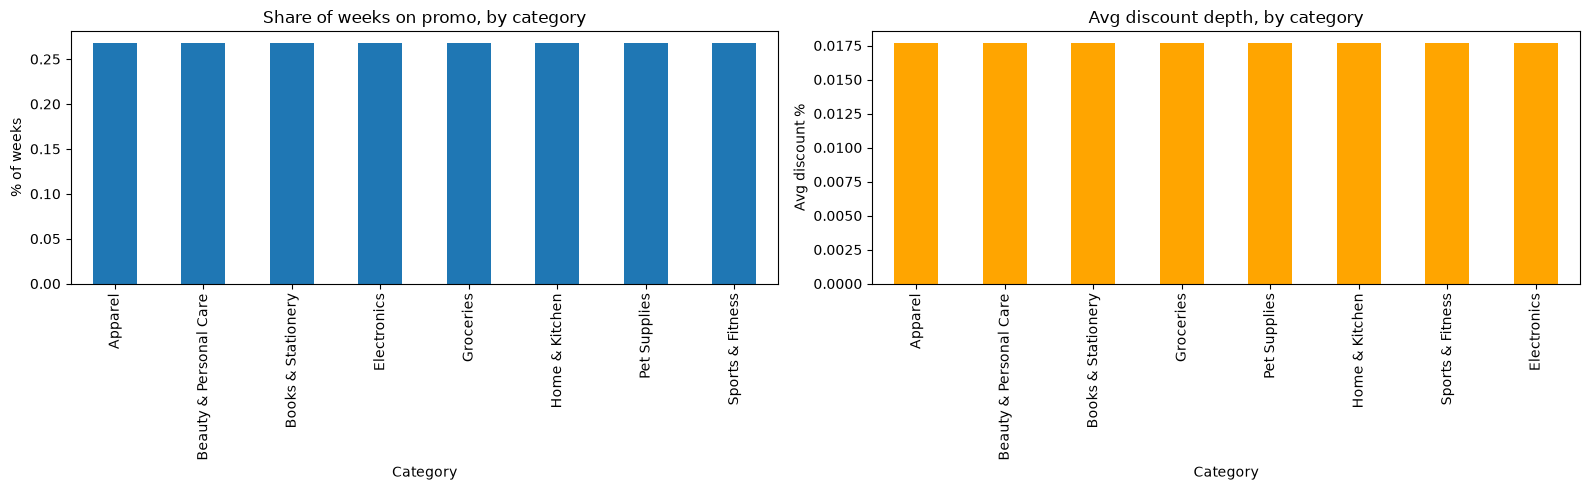

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

promo_rate = df.groupby('Category')['On_Promo'].mean().sort_values(ascending=False)
promo_rate.plot(kind='bar', ax=axes[0])
axes[0].set_title('Share of weeks on promo, by category')
axes[0].set_ylabel('% of weeks')

df.groupby('Category')['Avg_Discount_Pct'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Avg discount depth, by category')
axes[1].set_ylabel('Avg discount %')

plt.tight_layout()
plt.show()


**Note:** All categories exhibit nearly identical promotion exposure, with approximately **26.8% of weeks** on promotion and an average discount depth of **1.8%**. This reflects the structure of the data rather than an error: `promo_calendar.csv` records **store-wide promotional events** (e.g., Republic Day Sale) that apply uniformly to all SKUs on the same dates with the same recorded discount. Consequently, this chart confirms that promotion exposure is consistent across categories, while the impact of promotions on sales is examined separately in the sales lift analysis (Section 5).

## 3. Price vs. quantity - visual pre-check before elasticity modeling
Log-log scatter per category. A clear downward slope = elasticity signal Person B should pick up;
flat/noisy = low elasticity or other factors (stockouts, promos) dominating.

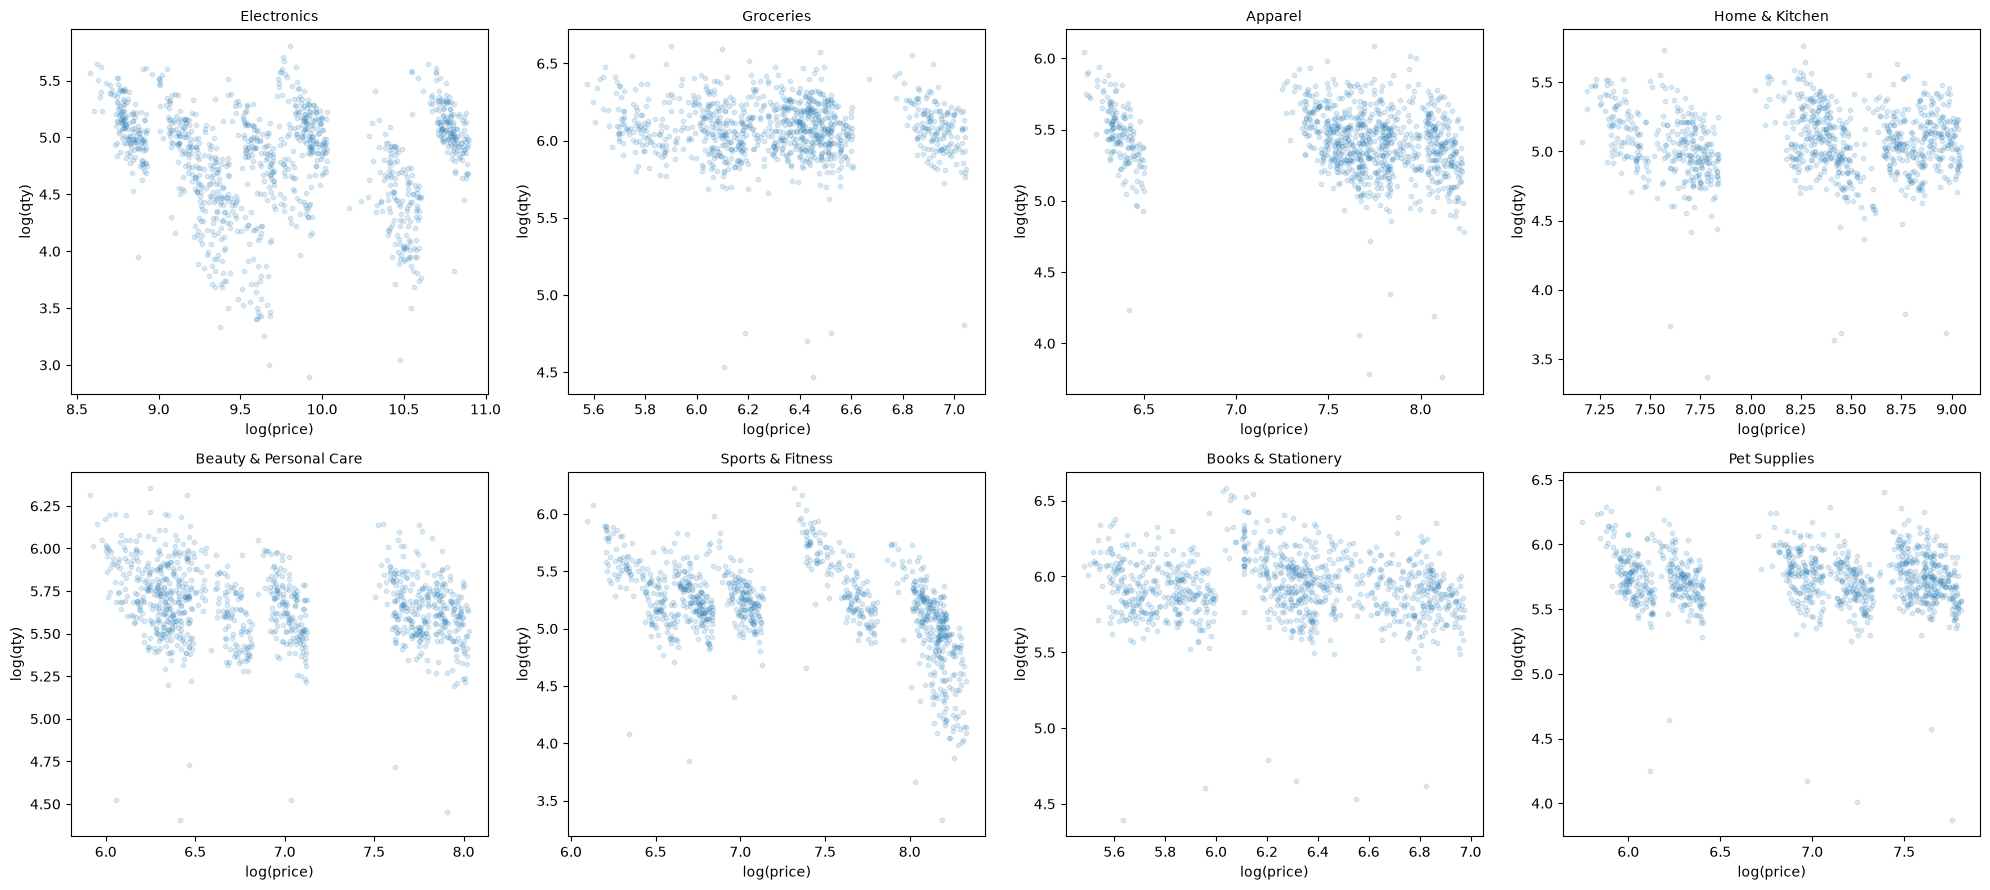

In [6]:
categories = df['Category'].unique()
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, cat in enumerate(categories):
    sub = df[(df['Category'] == cat) & df['Log_Price'].notnull()]
    axes[i].scatter(sub['Log_Price'], sub['Log_Qty'], alpha=0.15, s=10)
    axes[i].set_title(cat, fontsize=10)
    axes[i].set_xlabel('log(price)')
    axes[i].set_ylabel('log(qty)')

plt.tight_layout()
plt.show()

**Note:** The points form distinct vertical bands because each SKU has only a limited number of price changes over the three-year period; prices are manually set and remain unchanged for long intervals. As a result, most of the observed price variation reflects differences **across SKUs** rather than **within the same SKU over time**. This should be considered when estimating price elasticity, as the limited within-SKU price variation may reduce the precision of SKU-specific elasticity estimates.

## 4. Competitor Price Positioning
This analysis compares our prices with the average competitor price across product categories to identify potential pricing anomalies. The results provide an initial assessment of SKUs that may be priced above or below the market and help prioritize products for further elasticity-based analysis.

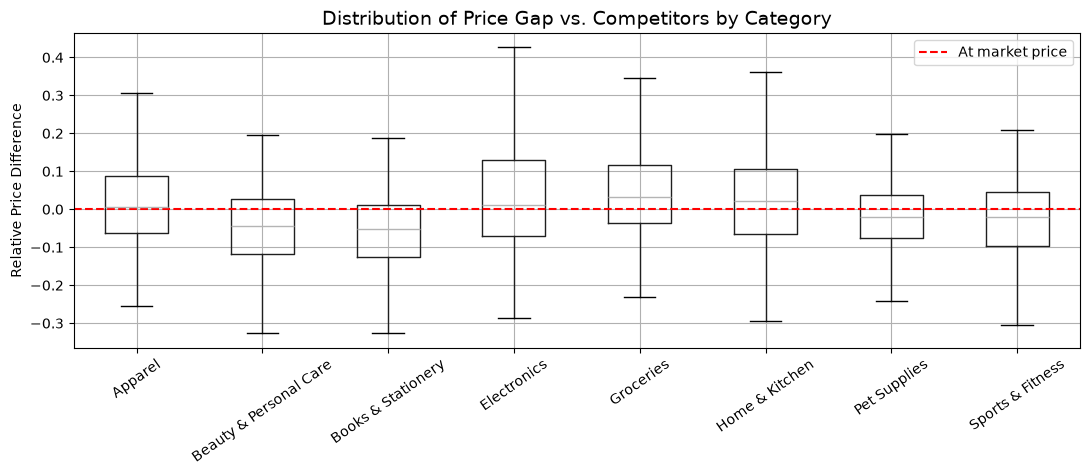

Top 5 Underpriced SKUs (vs Competitors)
SKU_ID   Category              
SKU0040  Books & Stationery       -18.09
SKU0043  Books & Stationery       -12.11
SKU0034  Sports & Fitness         -11.94
SKU0031  Beauty & Personal Care   -11.23
SKU0037  Sports & Fitness          -8.88
Name: Price_vs_Competitor_Gap_Pct, dtype: float64

Top 5 Overpriced SKUs (vs Competitors)
SKU_ID   Category      
SKU0013  Groceries         16.49
SKU0010  Groceries         17.41
SKU0022  Home & Kitchen    17.97
SKU0004  Electronics       23.48
SKU0007  Electronics       26.87
Name: Price_vs_Competitor_Gap_Pct, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(11, 5))

df.boxplot(
    column='Price_vs_Competitor_Gap_Pct',
    by='Category',
    ax=ax,
    rot=35,
    showfliers=False  # Hide extreme outliers for better readability
)
ax.axhline(
    0,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='At market price'
)
ax.set_title('Distribution of Price Gap vs. Competitors by Category', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Relative Price Difference')
ax.legend(loc='upper right')

plt.suptitle('')
plt.tight_layout()
plt.show()

sku_gap = (
    df.groupby(['SKU_ID', 'Category'])['Price_vs_Competitor_Gap_Pct']
      .mean()
      .mul(100)      # Convert to percentage
      .round(2)
      .sort_values()
)

print("Top 5 Underpriced SKUs (vs Competitors)")
print(sku_gap.head(5))

print("\nTop 5 Overpriced SKUs (vs Competitors)")
print(sku_gap.tail(5))

**Note:** The median price gap across most categories is close to zero, indicating that our prices are generally aligned with competitors. However, several categories (particularly Electronics, Groceries, and Home & Kitchen) show wider spreads and numerous outliers, suggesting that a subset of SKUs is priced substantially above or below the market. The SKU-level summary confirms this by identifying products that are consistently underpriced or overpriced, making them good candidates for pricing review and optimization.

## 5. Do promos actually move volume?
Overlay promo weeks against total quantity sold across all SKUs.

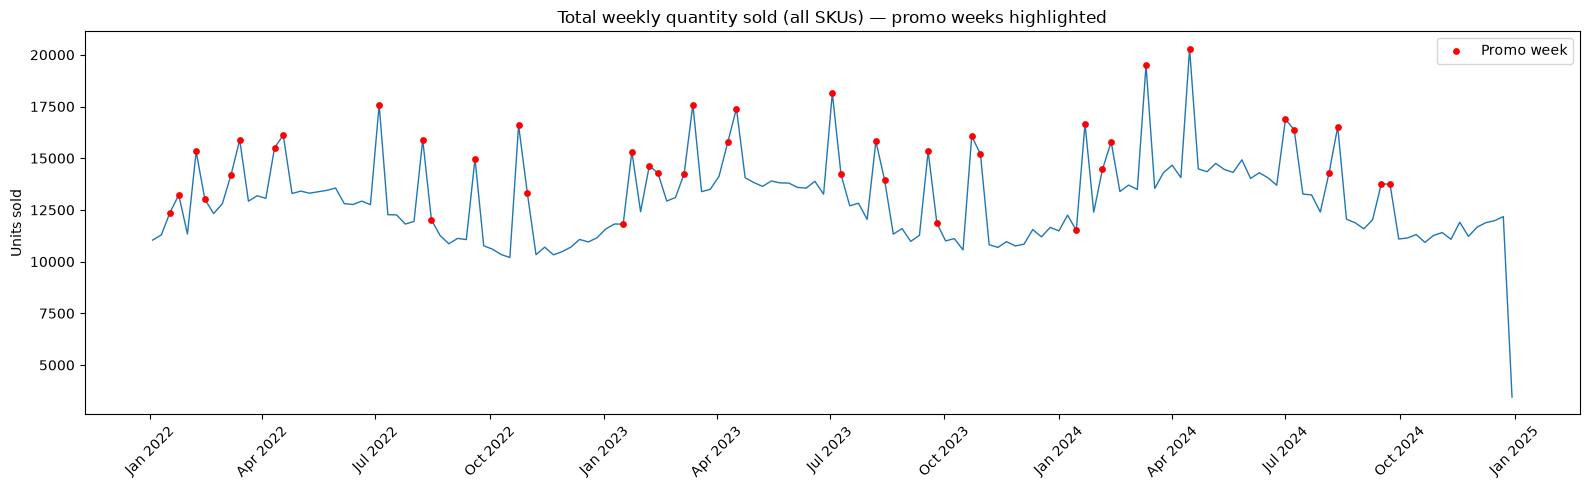

Avg weekly qty, non-promo: 12,256
Avg weekly qty, promo:     15,178
Lift: 23.8%


In [8]:
weekly_totals = df.groupby('Week_Start_Date').agg(
    Total_Qty=('Quantity_Sold','sum'),
    Any_Promo=('On_Promo', 'max')
).reset_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(weekly_totals['Week_Start_Date'], weekly_totals['Total_Qty'], linewidth=1)

promo_weeks = weekly_totals[weekly_totals['Any_Promo'] == True]
ax.scatter(promo_weeks['Week_Start_Date'], promo_weeks['Total_Qty'], color='red', s=15, zorder=5, label='Promo week')

ax.set_title('Total weekly quantity sold (all SKUs) — promo weeks highlighted')
ax.set_ylabel('Units sold')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

lift = weekly_totals.groupby('Any_Promo')['Total_Qty'].mean()
print(f"Avg weekly qty, non-promo: {lift[False]:,.0f}")
print(f"Avg weekly qty, promo:     {lift[True]:,.0f}")
print(f"Lift: {(lift[True]/lift[False] - 1)*100:.1f}%")

**Note:** Weekly sales are generally higher during promotion weeks, with an average of **15,178 units sold** compared to **12,256 units** during non-promotion weeks, representing an estimated **23.8% sales lift**. Most of the largest sales peaks coincide with promotions, indicating that promotional campaigns are effective at increasing demand. However, some high-sales weeks occur without promotions, suggesting that seasonality or other external factors also influence sales. The sharp decline in the final week is likely due to incomplete data and should not be interpreted as a genuine drop in demand.

## 6. Sample SKU time series - price & volume
Sanity-check a few individual SKUs before handing off to elasticity modeling.

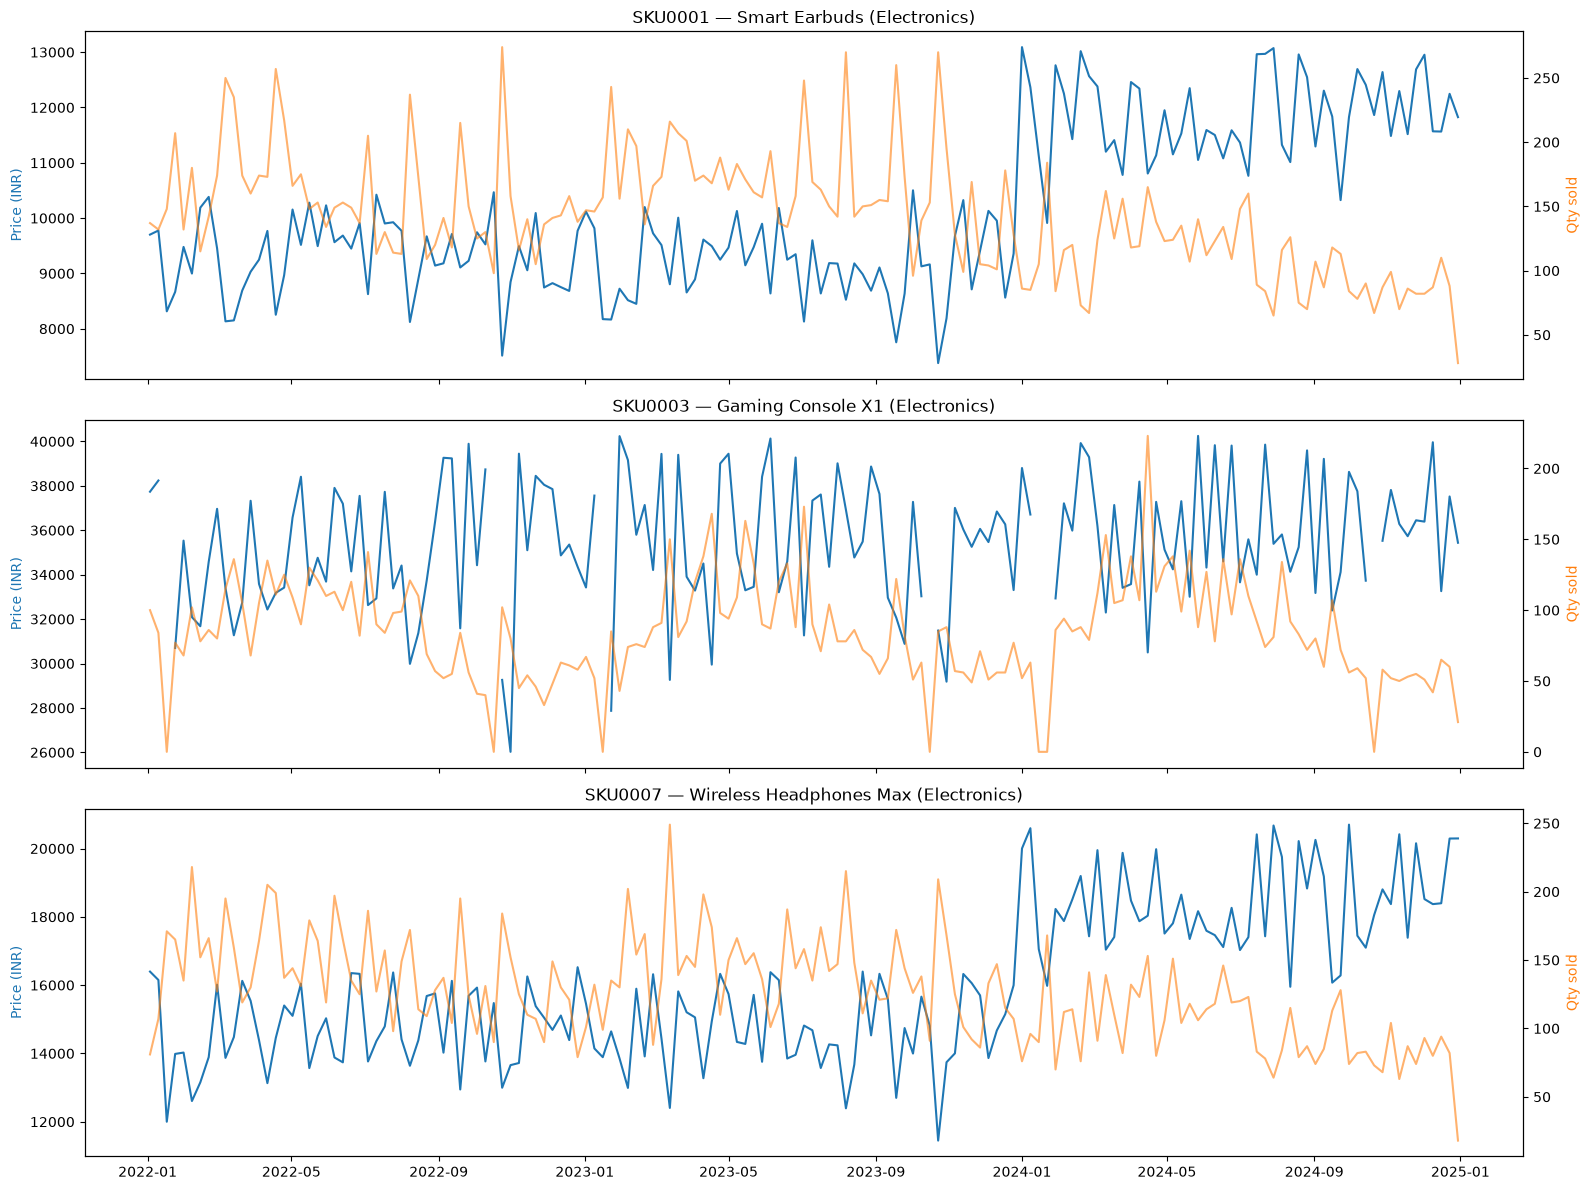

In [9]:
sample_skus = ['SKU0001', 'SKU0003', 'SKU0007']  # SKU0007 is the most overpriced vs. competitors (section 4)

fig, axes = plt.subplots(len(sample_skus), 1, figsize=(16, 4*len(sample_skus)), sharex=True)

for ax, sku in zip(axes, sample_skus):
    sub = df[df['SKU_ID'] == sku].sort_values('Week_Start_Date')
    ax2 = ax.twinx()
    ax.plot(sub['Week_Start_Date'], sub['Avg_Effective_Price_INR'], color='tab:blue', label='Price')
    ax2.plot(sub['Week_Start_Date'], sub['Quantity_Sold'], color='tab:orange', alpha=0.6, label='Qty sold')
    ax.set_title(f"{sku} — {sub['Product_Name'].iloc[0]} ({sub['Category'].iloc[0]})")
    ax.set_ylabel('Price (INR)', color='tab:blue')
    ax2.set_ylabel('Qty sold', color='tab:orange')

plt.tight_layout()
plt.show()

**Note:** The plots compare weekly prices and units sold for three representative Electronics SKUs over the study period. In several periods, decreases in price coincide with increases in quantity sold, suggesting a negative relationship between price and demand. However, this pattern is not consistent throughout the time series, indicating that sales are also influenced by factors such as promotions, seasonality, and other market conditions. The substantial week-to-week variation in both price and sales supports the use of a regression model to quantify price elasticity rather than relying solely on visual inspection.

## 7. Zero-sales weeks - recurring pattern
21 SKU-weeks have `Quantity_Sold = 0`, concentrated in a few SKUs and clustering around
mid-January and mid-October. Worth investigating before modeling - likely a genuine
demand/inventory pattern, not a join error (see `data_dictionary.md`).

In [10]:
zero_weeks = df[df['Quantity_Sold'] == 0]
print(zero_weeks[['SKU_ID','Category','Week_Start_Date','Stockout_Flag','Beginning_Inventory_Units']])

       SKU_ID          Category Week_Start_Date  Stockout_Flag  Beginning_Inventory_Units
316   SKU0003       Electronics      2022-01-17            0.0                       50.0
355   SKU0003       Electronics      2022-10-17            0.0                     2000.0
368   SKU0003       Electronics      2023-01-16            0.0                     2650.0
407   SKU0003       Electronics      2023-10-16            0.0                     4600.0
420   SKU0003       Electronics      2024-01-15            0.0                     5250.0
421   SKU0003       Electronics      2024-01-22            0.0                     5300.0
460   SKU0003       Electronics      2024-10-21            0.0                     7250.0
473   SKU0004       Electronics      2022-01-17            0.0                       50.0
512   SKU0004       Electronics      2022-10-17            0.0                     2000.0
525   SKU0004       Electronics      2023-01-16            0.0                     2650.0
564   SKU0

**Note:** There are **21 SKU-weeks** with zero recorded sales, concentrated within a small number of SKUs and recurring around similar calendar weeks across multiple years. Since these observations have positive beginning inventory and no recorded stockout, they are unlikely to be explained by inventory shortages or a simple data join issue. Instead, they appear to represent a recurring business pattern that should be handled explicitly during modeling.

### Findings to carry forward

1. **Electronics exhibits the highest variability in margin (%)** (std ≈ 10.3%), followed by Sports & Fitness and Beauty & Personal Care, suggesting greater pricing inconsistency within these categories.

2. **Promotion weeks are associated with an average sales lift of approximately 24%** (12,256 -> 15,178 units/week). Since `Discount_Pct` alone may not fully capture promotional activity, the `On_Promo` indicator should be included as a separate explanatory variable.

3. **Competitor price gaps highlight potential pricing anomalies.** SKU0040/SKU0043 (Books & Stationery) are priced approximately 12-18% below competitors, while SKU0004/SKU0007 (Electronics) are priced around 23-27% above competitors. These SKUs warrant further investigation alongside elasticity estimates.

4. **Twenty-one SKU-weeks have zero recorded sales** despite positive beginning inventory and no recorded stockout. These observations should be handled explicitly during elasticity modeling (e.g., exclusion or an appropriate censored/zero-inflated approach) rather than producing undefined log values.

5. **Stockouts are rare (3 events in total)**, suggesting they are unlikely to materially affect elasticity estimation.